<a href="https://colab.research.google.com/github/KhanAmmarAhmed/Ai-ML/blob/main/Task1%262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('iris')

# OR load from CSV
# df = pd.read_csv('iris.csv')

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [ ]:
# Shape and columns
print(df.shape)        # (150, 5)
print(df.columns.tolist())

# Data types and nulls
df.info()

# Descriptive statistics
print(df.describe())

# Check class distribution
print(df['species'].value_counts())

(150, 5)
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.

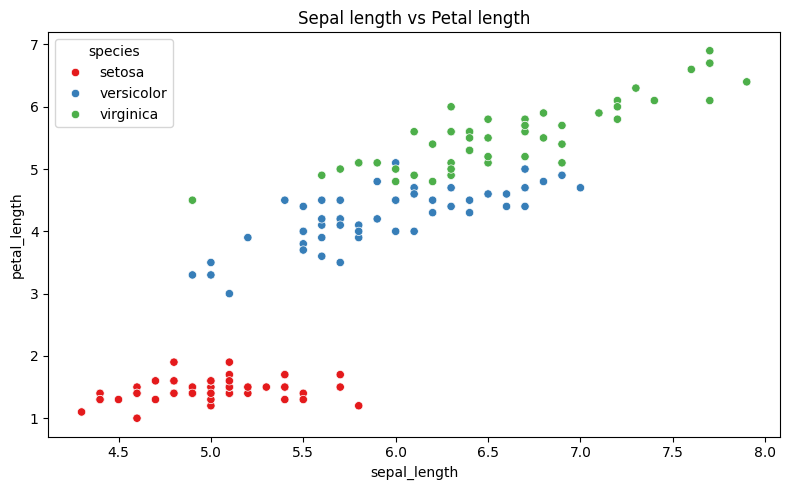

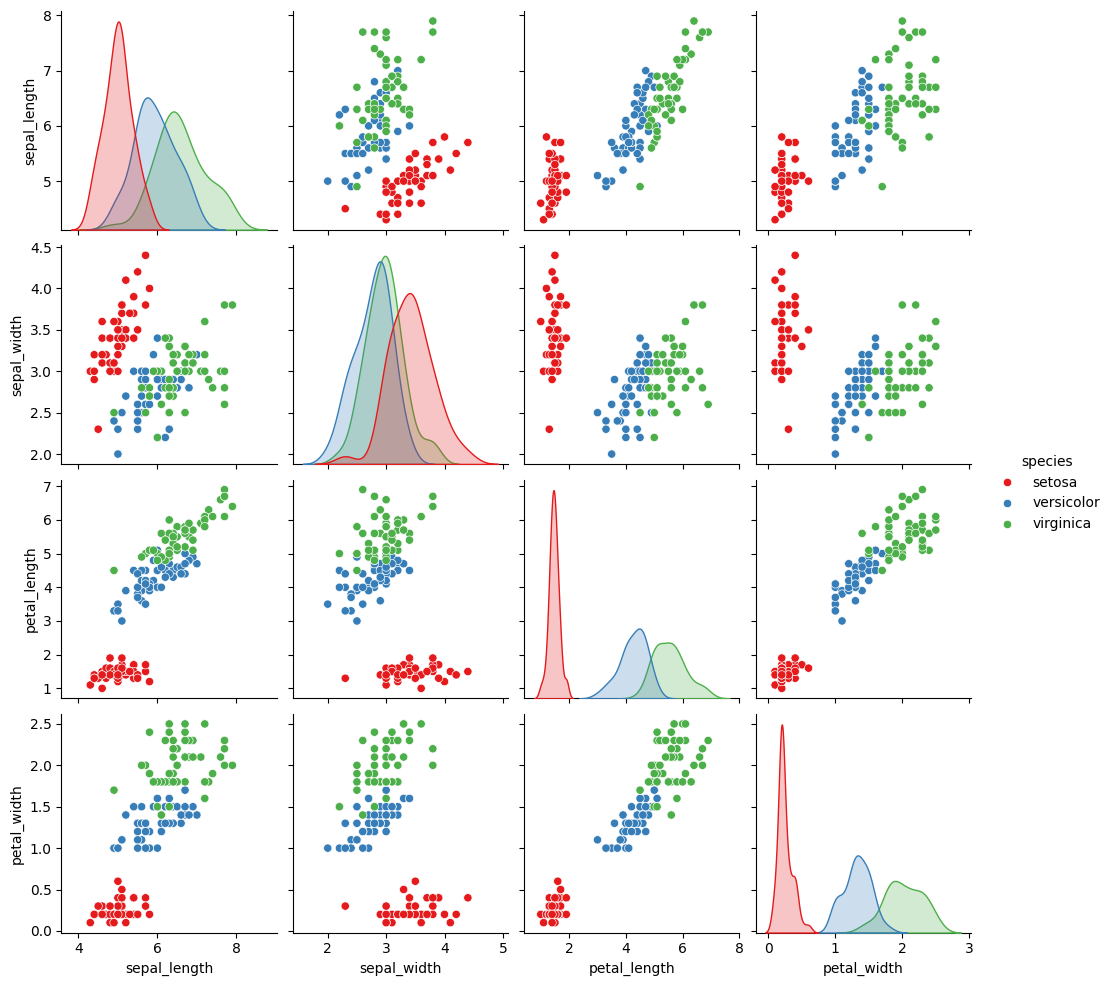

In [ ]:
# Single scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='sepal_length',
    y='petal_length',
    hue='species',
    palette='Set1'
)
plt.title('Sepal length vs Petal length')
plt.tight_layout()
plt.show()

# Full pairplot (all feature pairs)
sns.pairplot(df, hue='species', palette='Set1')
plt.show()

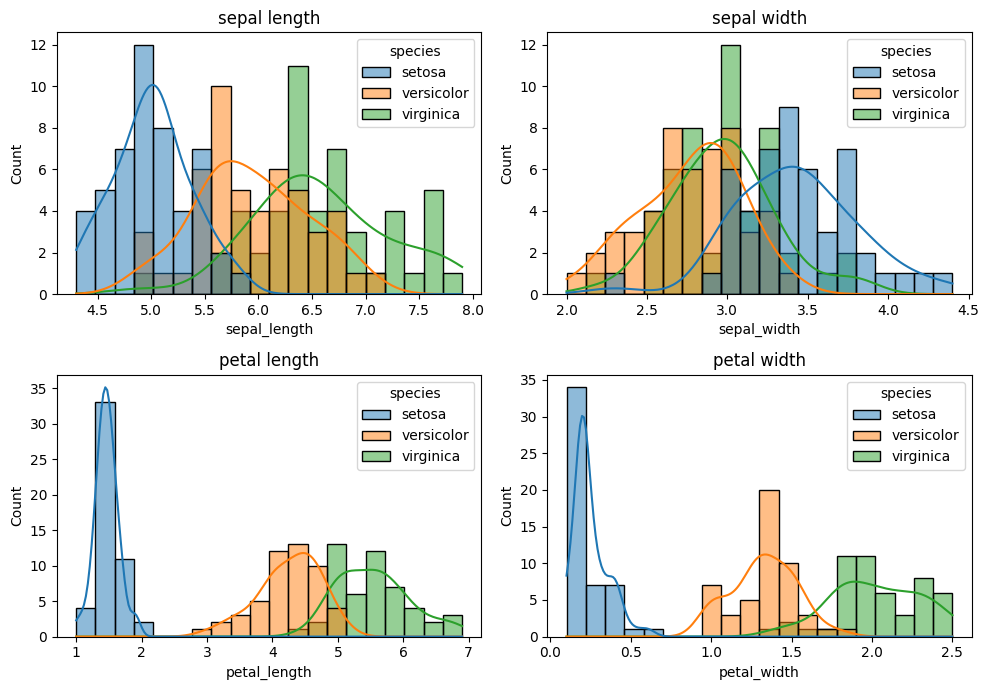

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
features = ['sepal_length', 'sepal_width',
            'petal_length', 'petal_width']

for ax, feat in zip(axes.flatten(), features):
    sns.histplot(
        data=df, x=feat,
        hue='species',
        kde=True,
        bins=20,
        ax=ax
    )
    ax.set_title(feat.replace('_', ' '))

plt.tight_layout()
plt.show()

/tmp/ipykernel_46459/892445735.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_46459/892445735.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_46459/892445735.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_46459/892445735.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_46459/892445735.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

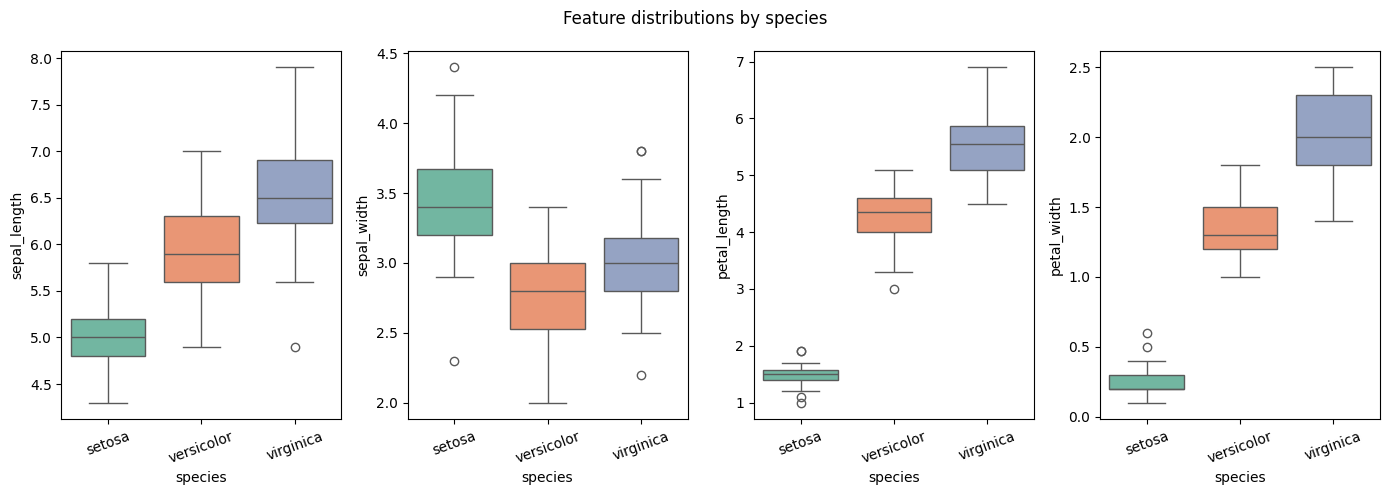

In [ ]:
# Box plot per feature grouped by species
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
features = ['sepal_length', 'sepal_width',
            'petal_length', 'petal_width']

for ax, feat in zip(axes, features):
    sns.boxplot(
        data=df,
        x='species',
        y=feat,
        palette='Set2',
        ax=ax
    )
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=20
    )

plt.suptitle('Feature distributions by species')
plt.tight_layout()
plt.show()

# ***Task: 2***   Predict Future Stock Prices (Short-Term)

In [ ]:
!pip install yfinance scikit-learn matplotlib pandas numpy -q

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ── Choose your stock ticker ──
TICKER = "AAPL"   # Change to "TSLA", "GOOGL", "MSFT" etc.
PERIOD = "2y"     # 2 years of data

print(f"📥 Downloading {TICKER} data from Yahoo Finance...")
df = yf.download(TICKER, period=PERIOD, auto_adjust=True)

# Flatten multi-level columns if present
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

print(f"✅ Loaded {len(df)} trading days")
print(f"   From : {df.index[0].date()}  →  To : {df.index[-1].date()}")
df.tail()   # Preview last 5 rows

📥 Downloading AAPL data from Yahoo Finance...


[*********************100%***********************]  1 of 1 completed

✅ Loaded 501 trading days
   From : 2024-05-16  →  To : 2026-05-15


,Close,High,Low,Open,Volume
Date,,,,,
2026-05-11,292.679993,293.880005,290.230011,291.980011,42247300
2026-05-12,294.799988,295.269989,292.559998,292.559998,45748100
2026-05-13,298.869995,300.920013,293.500000,293.500000,52684300
2026-05-14,298.209991,300.450012,295.380005,299.820007,35324900
2026-05-15,300.230011,303.200012,296.519989,297.899994,54721100


In [ ]:
# ── Create new features ──
df["MA_5"]       = df["Close"].rolling(5).mean()     # 5-day moving average
df["MA_20"]      = df["Close"].rolling(20).mean()    # 20-day moving average
df["Volatility"] = df["High"] - df["Low"]            # Daily price range
df["Return"]     = df["Close"].pct_change()          # Daily % return

# ── Target: NEXT day's closing price ──
df["Target"] = df["Close"].shift(-1)

# Drop rows with NaN (from rolling + shift)
df.dropna(inplace=True)

# ── Define features and label ──
FEATURES = ["Open", "High", "Low", "Volume", "MA_5", "MA_20", "Volatility", "Return"]
X = df[FEATURES]
y = df["Target"]

print(f"✅ Features  : {FEATURES}")
print(f"✅ Total rows after cleaning : {len(X)}")

✅ Features  : ['Open', 'High', 'Low', 'Volume', 'MA_5', 'MA_20', 'Volatility', 'Return']
✅ Total rows after cleaning : 481


In [ ]:
# ── Time-ordered split (NO shuffling!) ──
split_idx = int(len(X) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df.index[split_idx:]

print(f"🔀 Training samples : {len(X_train)}")
print(f"🔀 Testing  samples : {len(X_test)}")

🔀 Training samples : 384
🔀 Testing  samples : 97


In [ ]:
# Scale features for Linear Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Train
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

# Predict
y_pred_lr = lr.predict(X_test_sc)

# Evaluate
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
print(f"📐 Linear Regression → RMSE: ${rmse_lr:.2f}  |  R²: {r2_lr:.4f}")

📐 Linear Regression → RMSE: $4.55  |  R²: 0.8633


In [ ]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
print(f"🌲 Random Forest     → RMSE: ${rmse_rf:.2f}  |  R²: {r2_rf:.4f}")

🌲 Random Forest     → RMSE: $7.88  |  R²: 0.5898


In [ ]:
last_row   = X.iloc[[-1]]    # Most recent data point
next_lr    = lr.predict(scaler.transform(last_row))[0]
next_rf    = rf.predict(last_row)[0]
last_close = float(df["Close"].iloc[-1])

print(f"💰 Last known close price    : ${last_close:.2f}")
print(f"🔮 Linear Regression predicts: ${next_lr:.2f}  ({(next_lr-last_close)/last_close*100:+.2f}%)")
print(f"🔮 Random Forest predicts    : ${next_rf:.2f}  ({(next_rf-last_close)/last_close*100:+.2f}%)")

💰 Last known close price    : $298.21
🔮 Linear Regression predicts: $296.79  (-0.48%)
🔮 Random Forest predicts    : $278.05  (-6.76%)


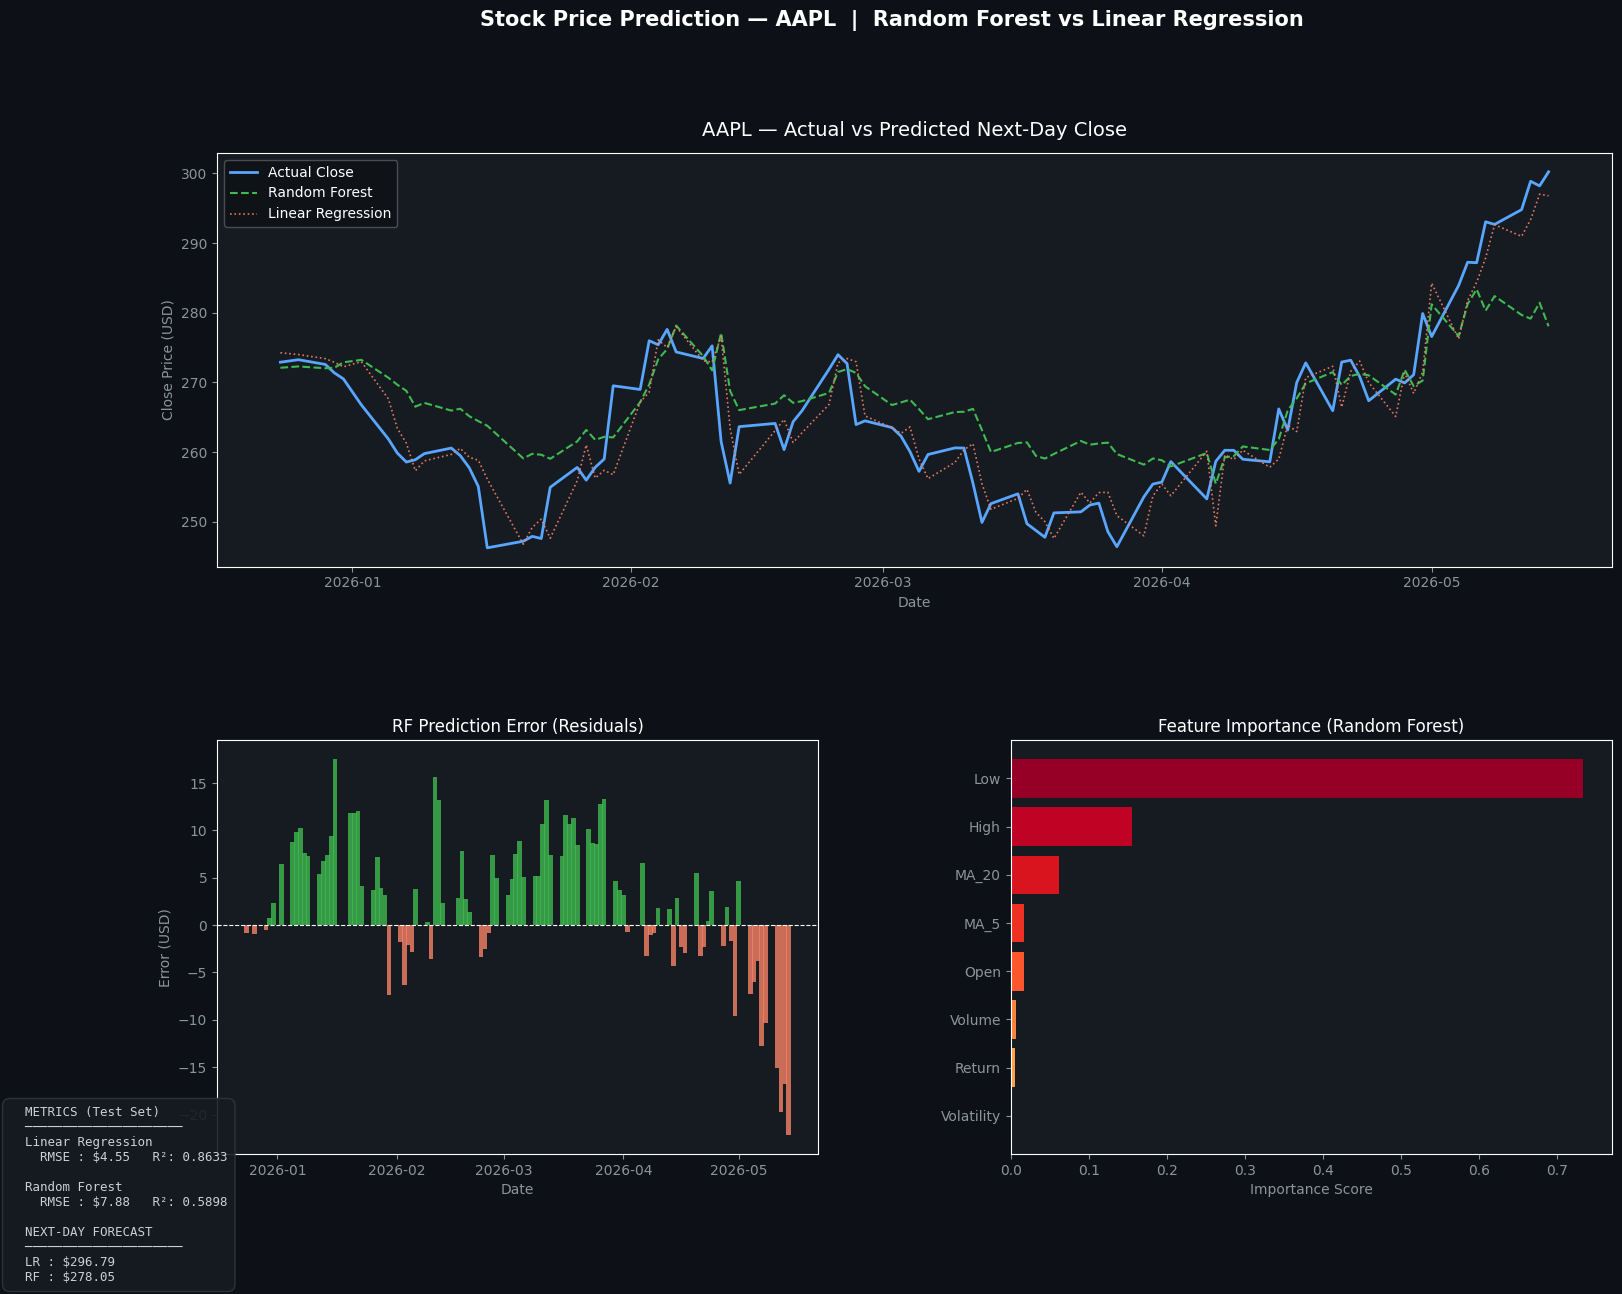

✅ Chart saved as stock_prediction.png


In [ ]:
plt.style.use("dark_background")
fig = plt.figure(figsize=(18, 13), facecolor="#0d1117")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# ── Panel 1: Actual vs Predicted ──────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(dates_test, y_test.values,  color="#58a6ff", lw=2.0, label="Actual Close")
ax1.plot(dates_test, y_pred_rf,      color="#3fb950", lw=1.5, ls="--", label="Random Forest")
ax1.plot(dates_test, y_pred_lr,      color="#f78166", lw=1.2, ls=":",  label="Linear Regression", alpha=0.9)
ax1.set_title(f"{TICKER} — Actual vs Predicted Next-Day Close", fontsize=14, color="white", pad=12)
ax1.set_xlabel("Date", color="#8b949e")
ax1.set_ylabel("Close Price (USD)", color="#8b949e")
ax1.legend(fontsize=10, framealpha=0.3)
ax1.tick_params(colors="#8b949e")
ax1.set_facecolor("#161b22")

# ── Panel 2: Residuals (Prediction Error) ─────────────────────
ax2 = fig.add_subplot(gs[1, 0])
errors = y_pred_rf - y_test.values
colors_bar = ["#3fb950" if e >= 0 else "#f78166" for e in errors]
ax2.bar(dates_test, errors, color=colors_bar, alpha=0.8, width=1.2)
ax2.axhline(0, color="white", lw=0.8, ls="--")
ax2.set_title("RF Prediction Error (Residuals)", fontsize=12, color="white")
ax2.set_xlabel("Date", color="#8b949e")
ax2.set_ylabel("Error (USD)", color="#8b949e")
ax2.tick_params(colors="#8b949e")
ax2.set_facecolor("#161b22")

# ── Panel 3: Feature Importance ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
colors_imp = plt.cm.YlOrRd(np.linspace(0.35, 0.95, len(importance)))
ax3.barh(importance.index, importance.values, color=colors_imp)
ax3.set_title("Feature Importance (Random Forest)", fontsize=12, color="white")
ax3.set_xlabel("Importance Score", color="#8b949e")
ax3.tick_params(colors="#8b949e")
ax3.set_facecolor("#161b22")

# ── Metrics Summary Box ───────────────────────────────────────
metrics = (
    f"  METRICS (Test Set)\n"
    f"  ─────────────────────\n"
    f"  Linear Regression\n"
    f"    RMSE : ${rmse_lr:.2f}   R²: {r2_lr:.4f}\n\n"
    f"  Random Forest\n"
    f"    RMSE : ${rmse_rf:.2f}   R²: {r2_rf:.4f}\n\n"
    f"  NEXT-DAY FORECAST\n"
    f"  ─────────────────────\n"
    f"  LR : ${next_lr:.2f}\n"
    f"  RF : ${next_rf:.2f}"
)
fig.text(0.01, 0.01, metrics, fontsize=9, color="#c9d1d9",
         fontfamily="monospace", va="bottom",
         bbox=dict(boxstyle="round,pad=0.6", facecolor="#161b22",
                   edgecolor="#30363d", alpha=0.9))

fig.suptitle(f"Stock Price Prediction — {TICKER}  |  Random Forest vs Linear Regression",
             fontsize=15, color="white", fontweight="bold", y=0.99)

plt.savefig("stock_prediction.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("✅ Chart saved as stock_prediction.png")